In [2]:
#Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [3]:
#Load Dataset

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)     

In [4]:
#Dataset Information
print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())


Shape of Dataset:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Sour

In [5]:
#Check Null values
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [6]:
#Check Duplicate Values

print(df.duplicated().sum())

0


In [7]:
#Dataset Statistical summary
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


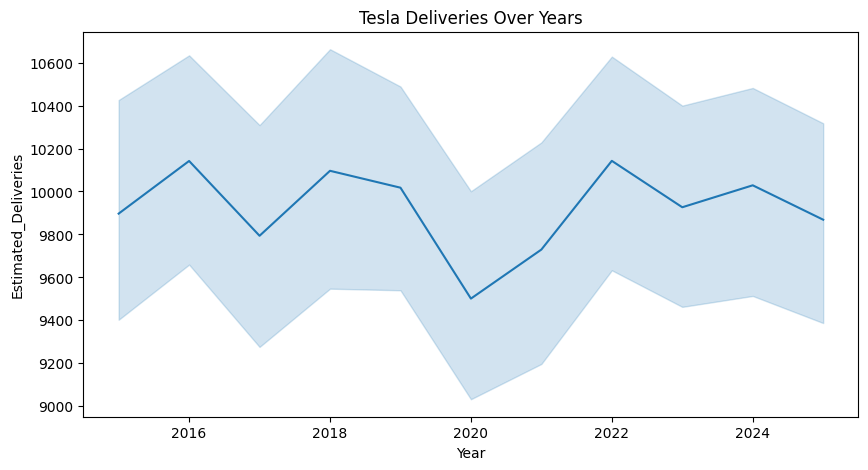

In [8]:
#Exploratory Data Analysis (EDA) :

#Deliveries Trend

plt.figure(figsize=(10,5))

sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Deliveries Over Years")

plt.show()

#Deliveries Trend Graph Observation:

Tesla estimated deliveries show a generally increasing tred over the years. But a slight drop can be observed during the year 2020, and the deliveries recovered again in the following years.

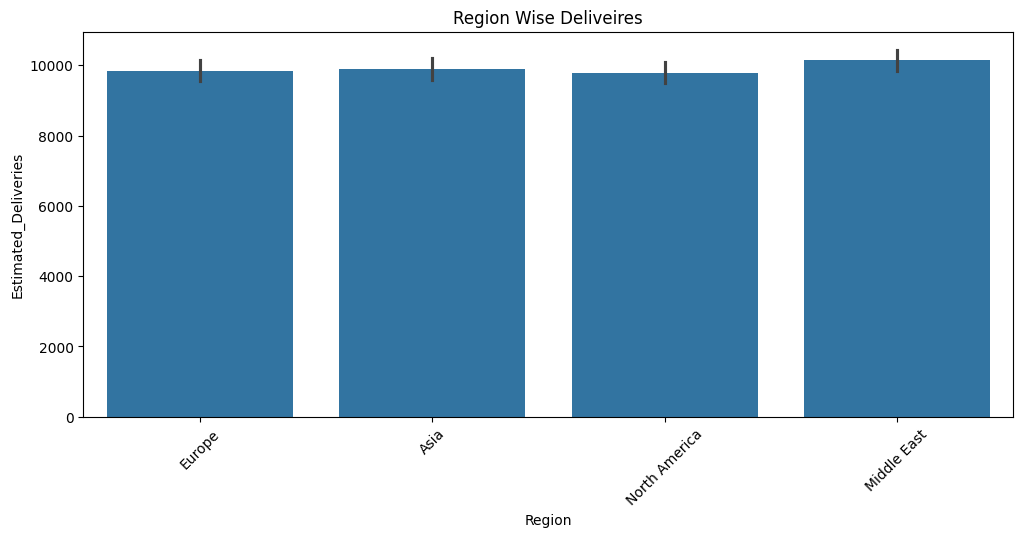

In [9]:
#Region Wise Deliveries

plt.figure(figsize=(12,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df 
)

plt.xticks(rotation=45)
plt.title("Region Wise Deliveires")
plt.show()

#Region Wise Deliveries Graph Observation:
The estimated deliveries are relatively balanced across different regions. Middle East and Asia regions show slightly higher deliveries compared to other regions.

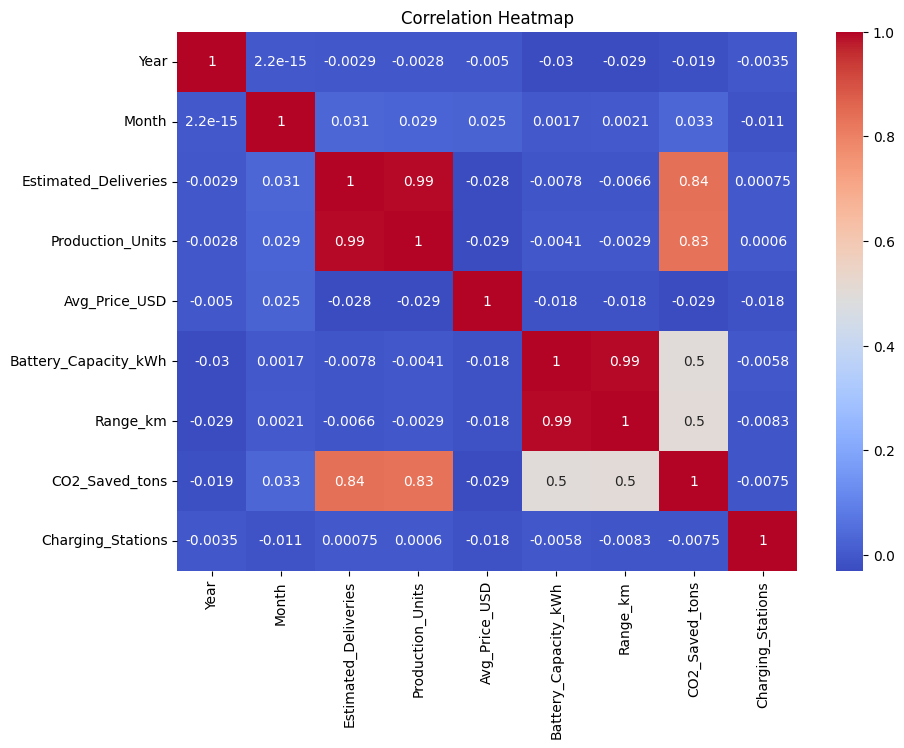

In [10]:
#Correlation Heatmap

plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

#Correlation Heatmap Observation:

Estimated deliveries and production units have a very high positive correlation.

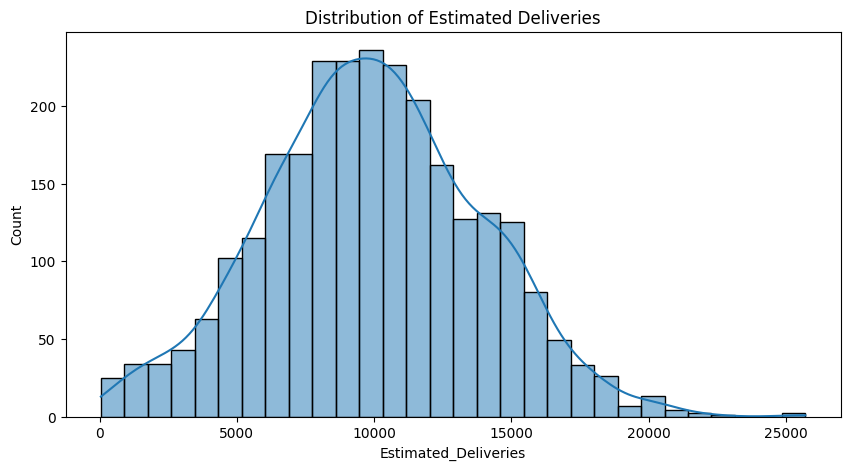

In [11]:
#Distribution Plot

plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated_Deliveries'],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")

plt.show()

#Distribution Plot Observation:
The distributiion of estimated deliveries appears normal with slight right skewness. Most delivery values are focused between 7000  and 15000.

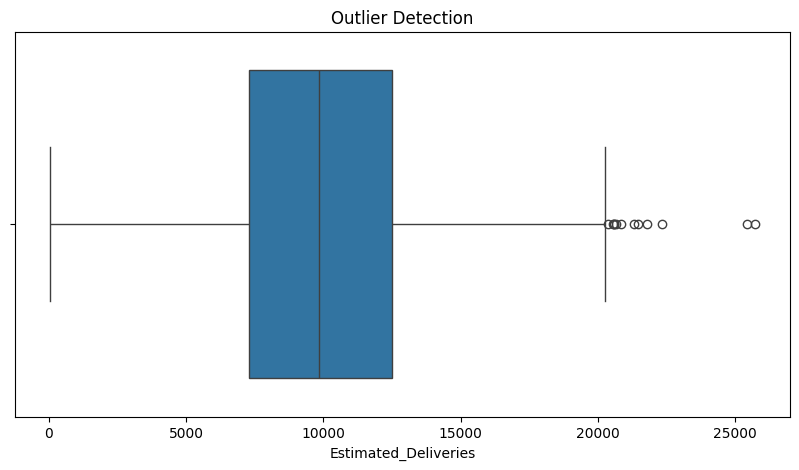

In [12]:
#Boxplot

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Estimated_Deliveries']
)

plt.title("Outlier Detection")

plt.show()

#Boxplot Observation:

Somme Outliers are present in the estimated deliveries column. Most of the data points are distributed within a range.

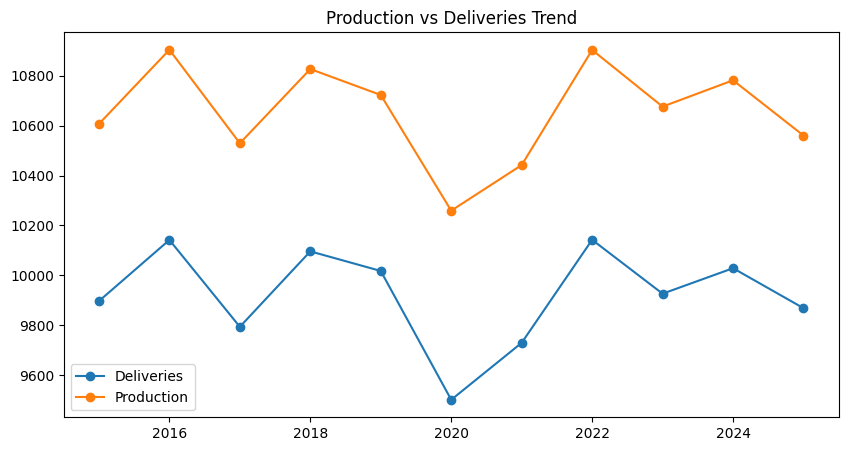

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    df.groupby('Year')['Estimated_Deliveries'].mean(),
    marker='o',
    label='Deliveries'
)

plt.plot(
    df.groupby('Year')['Production_Units'].mean(),
    marker='o',
    label='Production'
)

plt.legend()

plt.title("Production vs Deliveries Trend")

plt.show()

# Production vs Deliveries Trend 
# Observation:
Production and delivery trends move closellly together over  time, indicating strong operational alignent.

In [15]:
#Feature Engineering

encoder = LabelEncoder()

df['Region'] = encoder.fit_transform(df['Region'])
df['Model'] = encoder.fit_transform(df['Model'])
df['Source_Type'] = encoder.fit_transform(df['Source_Type'])

print("Categorical Columns Encoded")

Categorical Columns Encoded


In [16]:
#Features and Target Variable

x = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

In [17]:
#Train_Test_Split the data

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 11)
Testing Shape: (528, 11)


In [18]:
#Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("linear Regression Model Trained")

linear Regression Model Trained


In [19]:
#Random Forest Regressor

rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained")

Random Forest Model Trained


In [20]:
#Model Evauation

print("--------Linear Regression Evaluation--------")

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:", r2_score(y_test, lr_pred))

print("\n--------Random Forest Evaluation--------")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))



--------Linear Regression Evaluation--------
MAE: 310.13002154682147
RMSE: 383.57656987039064
R2 Score: 0.9901296027802067

--------Random Forest Evaluation--------
MAE: 323.46011363636364
RMSE: 409.4960252956731
R2 Score: 0.9887505867840798


In [21]:
#HyperParameter  Tuning

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=3
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}


In [32]:
#Time series Forecasting

yearly_data = df.groupby("Year")['Estimated_Deliveries'].sum()

model = ARIMA(yearly_data, order=(1,1,1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

forecast_df = pd.DataFrame({
    'Year': future_years,
    'Forecasted_Deliveries': forecast.values.astype(int)
})

forecast_df

,Year,Forecasted_Deliveries
0,2026,2366761
1,2027,2367843
2,2028,2367154
3,2029,2367593
4,2030,2367314


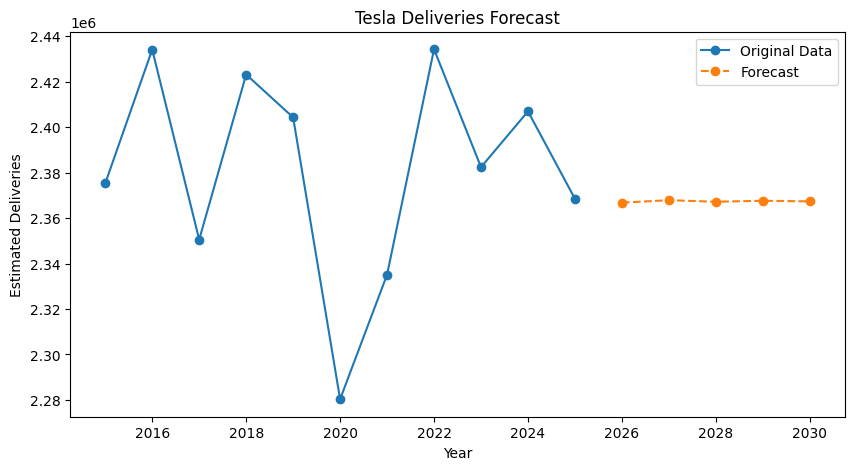

In [23]:
#Forecast Visualization

plt.figure(figsize=(10,5))

plt.plot(
    yearly_data.index,
    yearly_data.values,
    marker='o',
    label='Original Data'
)

future_years = np.arange(
    yearly_data.index.max() +1,
    yearly_data.index.max() +6
)

plt.plot(
    future_years,
    forecast,
    marker='o',
    linestyle='dashed',
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.legend()
plt.show()

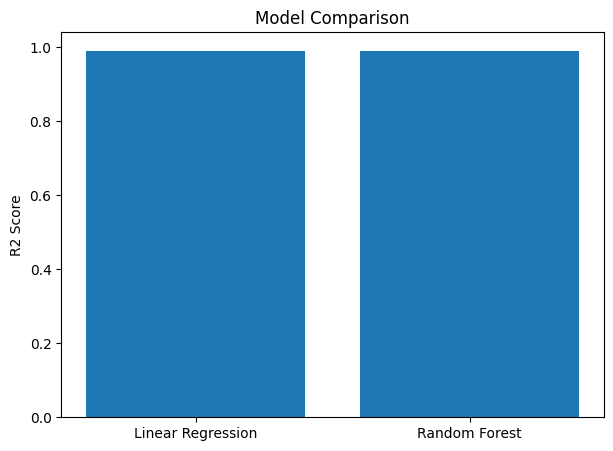

In [24]:
#Model Comparison.

models = ['Linear Regression', 'Random Forest']

scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(7,5))

plt.bar(models, scores)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

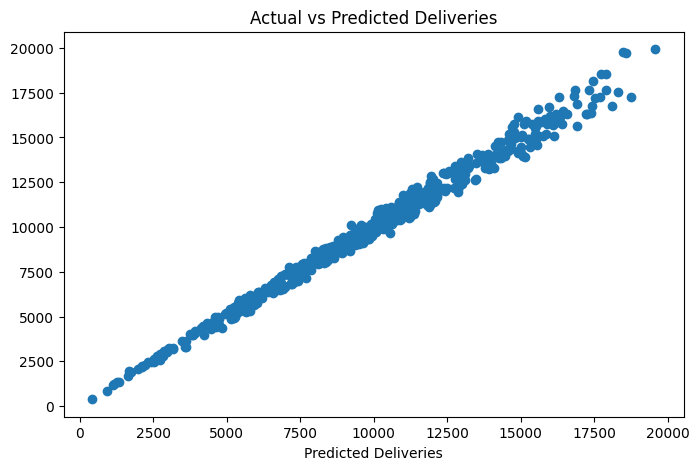

In [ ]:
#Actual vs Predicted Graph 

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Deliveries")
plt.xlabel("Predicted Deliveries")

plt.title("Actual vs Predicted Deliveries")

plt.show()

#Observation :

Most prediction lie close to actual values, indicating good model performance.

# Scenario Analysis:

If Tesla production increases significantly in future years, estimated deliveries are also expected to increase because both varaibles show strong positive correlation.